In [1]:
# Import packages
import os
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python.vision import PoseLandmarker, PoseLandmarkerOptions
from mediapipe.tasks.python import BaseOptions
import pandas as pd
from tqdm import tqdm
import urllib.request
import numpy as np

In [2]:
# Configure directories
UCF_VIDEOS = "UCF-101"
UCF_SPLITS = "UCF101TrainTestSplits/ucfTrainTestlist"
FRAMES_DIR = "outputs/frames"
KEYPOINTS_DIR = "outputs/keypoints"

# Convert UCF101 classes to our labels
EXERCISE_CLASSES = {
    "PushUps": "pushups", 
    "BodyWeightSquats": "squats",
    "Lunges": "lunges",
    "PullUps": "pullups",
}

# Configure desired frame rates and image size
TARGET_FPS = 10
IMG_SIZE = (640, 480)

In [3]:
# Filter 5 classes from the train/test split

def load_videos():
    rows = []
    for split, filename in [("train", "trainlist01.txt"), ("test", "testlist01.txt")]:
        filepath = os.path.join(UCF_SPLITS, filename)
        with open(filepath) as f:
            for line in f: # e.g. BodyWeightSquats/v_BodyWeightSquats_g08_c01.avi
                rel_path = line.strip().split()[0]
                class_name = rel_path.split("/")[0]
                if class_name not in EXERCISE_CLASSES:
                    continue
                rows.append({
                    "video_path": os.path.join(UCF_VIDEOS, rel_path),
                    "label": EXERCISE_CLASSES[class_name],
                    "split": split,
                    "video_name": os.path.splitext(os.path.basename(rel_path))[0]
                })
    df = pd.DataFrame(rows)
    print(f"Found {len(df)} exercise videos\n{df['label'].value_counts()}\n")
    return df

In [4]:
# Extract frames from the videos
def extract_frames(video_df):
    rows = []
    for _, row in tqdm(video_df.iterrows(), total=len(video_df), desc="Extracting keyframes"):
        save_dir = os.path.join(FRAMES_DIR, row["split"], row["label"], row["video_name"])
        os.makedirs(save_dir, exist_ok=True)

        # Use OpenCV to open the .avi file
        # Checks the video's native FPS and determines how many frames to get based on that
        cap = cv2.VideoCapture(row["video_path"])
        fps = cap.get(cv2.CAP_PROP_FPS) or TARGET_FPS
        frame_interval = max(1, int(round(fps / TARGET_FPS)))

        frame_idx = 0 # Tracks every frame seens
        saved_idx = 0 # Tracks only the frames to save

        while True:
            ret, frame = cap.read()
            if not ret:
                break # Ret = False once the video has ended, so break
            if frame_idx % frame_interval == 0: # Resize and save frames in wanted interval
                frame_path = os.path.join(save_dir, f"frame_{saved_idx:04d}.jpg")
                cv2.imwrite(frame_path, cv2.resize(frame, IMG_SIZE))
                rows.append({**row, "frame_path": frame_path, "frame_index": saved_idx})
                saved_idx += 1
            frame_idx += 1
        cap.release() # Closes the video
    df = pd.DataFrame(rows)
    print(f"Extracted {len(df)} frames total\n")
    return df

In [5]:
# Name keypoints according to MediaPipe Pose standards
KEYPOINT_NAMES = [
    "nose", "left_eye_inner", "left_eye", "left_eye_outer",
    "right_eye_inner", "right_eye", "right_eye_outer",
    "left_ear", "right_ear", "mouth_left", "mouth_right",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_pinky", "right_pinky",
    "left_index", "right_index", "left_thumb", "right_thumb",
    "left_hip", "right_hip", "left_knee", "right_knee",
    "left_ankle", "right_ankle", "left_heel", "right_heel",
    "left_foot_index", "right_foot_index",
]

# Download the MediaPipe Pose model
MODEL_PATH = "pose_landmarker.task"
if not os.path.exists(MODEL_PATH):
    print("Downloading pose model...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task",
        MODEL_PATH
    )
    print("Downloaded!")

# Extract keypoints 
def extract_keypoints(frame_df):
    os.makedirs(KEYPOINTS_DIR, exist_ok=True)
    options = PoseLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=mp.tasks.vision.RunningMode.IMAGE,
        num_poses=1,
        min_pose_detection_confidence=0.5,
    )
    rows = []
    with PoseLandmarker.create_from_options(options) as landmarker:
        # Loop through each frame in the dataframe
        for _, row in tqdm(frame_df.iterrows(), total=len(frame_df), desc="Pose estimation"):
            frame = cv2.imread(row["frame_path"])
            if frame is None:
                continue
            
            # Run MediaPipe on the frame after converting to RGB
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            results = landmarker.detect(mp_image)
            if not results.pose_landmarks:
                continue

            landmarks = results.pose_landmarks[0]
            keypoints = {}
            for i, name in enumerate(KEYPOINT_NAMES):
                kp = landmarks[i]
                # x and y-> position on screen
                keypoints[f"{name}_x"]   = round(kp.x, 6)
                keypoints[f"{name}_y"]   = round(kp.y, 6)

            rows.append({
                "frame_path": row["frame_path"],
                "video_name": row["video_name"],
                "label": row["label"],
                "split": row["split"],
                "frame_index": row["frame_index"],
                **keypoints # Append entire keyframes dictionary at once
            })

    df = pd.DataFrame(rows)
    # Output two CSVs that the model will train on (train and test keypoints)
    for split, group in df.groupby("split"):
        out_path = os.path.join(KEYPOINTS_DIR, f"{split}_keypoints.csv")
        group.to_csv(out_path, index=False)
        print(f"Saved {len(group)} rows → {out_path}")
        print(group["label"].value_counts(), "\n")
    return df

In [6]:
video_df = load_videos()
frame_df = extract_frames(video_df)
extract_keypoints(frame_df)

Found 441 exercise videos
label
lunges     127
squats     112
pushups    102
pullups    100
Name: count, dtype: int64



Extracting keyframes: 100%|██████████| 441/441 [02:01<00:00,  3.63it/s]


Extracted 30542 frames total



Pose estimation: 100%|██████████| 30542/30542 [15:38<00:00, 32.56it/s]


Saved 6681 rows → outputs/keypoints\test_keypoints.csv
label
lunges     2952
squats     1812
pushups     980
pullups     937
Name: count, dtype: int64 

Saved 19006 rows → outputs/keypoints\train_keypoints.csv
label
lunges     8564
squats     5312
pullups    2819
pushups    2311
Name: count, dtype: int64 



,frame_path,video_name,label,split,frame_index,nose_x,nose_y,left_eye_inner_x,left_eye_inner_y,left_eye_x,...,right_ankle_x,right_ankle_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y,left_foot_index_x,left_foot_index_y,right_foot_index_x,right_foot_index_y
0,outputs/frames\train\squats\v_BodyWeightSquats...,v_BodyWeightSquats_g08_c01,squats,train,0,0.498673,0.326496,0.498823,0.310232,0.500799,...,0.418064,0.926531,0.502136,0.951608,0.416589,0.943314,0.521340,0.987345,0.437218,0.987540
1,outputs/frames\train\squats\v_BodyWeightSquats...,v_BodyWeightSquats_g08_c01,squats,train,1,0.500554,0.326976,0.500588,0.310929,0.502863,...,0.416381,0.922342,0.515106,0.950867,0.417111,0.942610,0.539033,0.987205,0.431652,0.986853
2,outputs/frames\train\squats\v_BodyWeightSquats...,v_BodyWeightSquats_g08_c01,squats,train,2,0.499823,0.333185,0.499327,0.315805,0.501402,...,0.418781,0.929287,0.501734,0.939595,0.416618,0.949759,0.534167,0.994335,0.434127,0.993849
3,outputs/frames\train\squats\v_BodyWeightSquats...,v_BodyWeightSquats_g08_c01,squats,train,3,0.498956,0.325757,0.499174,0.310002,0.501396,...,0.416944,0.929216,0.502690,0.939821,0.408781,0.947273,0.539880,0.989181,0.434386,0.992563
4,outputs/frames\train\squats\v_BodyWeightSquats...,v_BodyWeightSquats_g08_c01,squats,train,4,0.502800,0.319947,0.501783,0.304821,0.503626,...,0.414609,0.930650,0.514345,0.958497,0.416563,0.932616,0.542549,0.990175,0.433984,0.993992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25682,outputs/frames\test\pushups\v_PushUps_g07_c04\...,v_PushUps_g07_c04,pushups,test,33,0.491798,0.741182,0.504473,0.722548,0.511692,...,0.463961,0.596942,0.560517,0.595279,0.465687,0.575658,0.560055,0.663198,0.476345,0.633492
25683,outputs/frames\test\pushups\v_PushUps_g07_c04\...,v_PushUps_g07_c04,pushups,test,34,0.459866,0.624580,0.474851,0.611060,0.480182,...,0.450235,0.766787,0.518398,0.703976,0.450736,0.755018,0.536200,0.724278,0.461990,0.794594
25684,outputs/frames\test\pushups\v_PushUps_g07_c04\...,v_PushUps_g07_c04,pushups,test,36,0.485839,0.422360,0.497983,0.404252,0.503457,...,0.421034,0.497498,0.525097,0.510711,0.430590,0.484257,0.556674,0.577655,0.427744,0.554614
25685,outputs/frames\test\pushups\v_PushUps_g07_c04\...,v_PushUps_g07_c04,pushups,test,37,0.474144,0.419561,0.489614,0.402014,0.495636,...,0.405623,0.473469,0.535121,0.495098,0.414505,0.468439,0.567136,0.551393,0.405220,0.512244


In [ ]:
# Delete unnecessary keypoints
useful_keypoints = [
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle", 
    "nose", "left_ear", "right_ear"
]

train_df = pd.read_csv("outputs/keypoints/train_keypoints.csv")
keep_cols = ["frame_path", "video_name", "label", "split", "frame_index"]
for kp in useful_keypoints:
    keep_cols += [f"{kp}_x", f"{kp}_y"]

train_df = train_df[keep_cols]
train_df.to_csv("outputs/keypoints/train_keypoints.csv", index=False)

test_df = pd.read_csv("outputs/keypoints/test_keypoints.csv")
keep_cols = ["frame_path", "video_name", "label", "split", "frame_index"]
for kp in useful_keypoints:
    keep_cols += [f"{kp}_x", f"{kp}_y"]

test_df = test_df[keep_cols]
test_df.to_csv("outputs/keypoints/test_keypoints.csv", index=False)

## Feature Computation and Labeling

In [27]:
def compute_angle(a, b, c):
    """Angle at point b, formed by a-b-c"""
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))

def add_angles(df):
    def angle(r, a, b, c):
        """Helper to pull x/y from row and compute angle at b"""
        return compute_angle(
            (r[f"{a}_x"], r[f"{a}_y"]),
            (r[f"{b}_x"], r[f"{b}_y"]),
            (r[f"{c}_x"], r[f"{c}_y"])
        )

    # KNEE ANGLES (squats, lunges) 
    for side in ["left", "right"]:
        df[f"{side}_knee_angle"] = df.apply(
            lambda r, s=side: angle(r, f"{s}_hip", f"{s}_knee", f"{s}_ankle"), axis=1)

    # ELBOW ANGLES (push-ups, pull-ups)
    for side in ["left", "right"]:
        df[f"{side}_elbow_angle"] = df.apply(
            lambda r, s=side: angle(r, f"{s}_shoulder", f"{s}_elbow", f"{s}_wrist"), axis=1)

    # HIP ANGLES (squats, lunges, pull-ups)
    for side in ["left", "right"]:
        df[f"{side}_hip_angle"] = df.apply(
            lambda r, s=side: angle(r, f"{s}_shoulder", f"{s}_hip", f"{s}_knee"), axis=1)

    # BODY LINE / HIP SAG (push-ups)
    for side in ["left", "right"]:
        df[f"{side}_body_line"] = df.apply(
            lambda r, s=side: angle(r, f"{s}_shoulder", f"{s}_hip", f"{s}_ankle"), axis=1)

    # TORSO UPRIGHTNESS (lunges, squats)
    # Angle between vertical and the shoulder-hip vector
    df["torso_angle"] = df.apply(lambda r: compute_angle(
        (r["left_shoulder_x"], r["left_shoulder_y"] - 0.1),  # point above shoulder
        (r["left_shoulder_x"], r["left_shoulder_y"]),
        (r["left_hip_x"],      r["left_hip_y"])
    ), axis=1)

    # KNEE BEND (squats, lunges)
    # How far knee is inside/outside the ankle - not an angle, just a distance
    for side in ["left", "right"]:
        df[f"{side}_knee_bend"] = df[f"{side}_knee_x"] - df[f"{side}_ankle_x"]

    # HEAD DROP (push-ups) 
    df["head_drop"] = df["nose_y"] - df["left_shoulder_y"]

    # SHOULDER SHRUG (pull-ups)
    for side in ["left", "right"]:
        df[f"{side}_shoulder_shrug"] = df[f"{side}_ear_y"] - df[f"{side}_shoulder_y"]

    # SHOULDER ANGLE (pull-ups)
    for side in ["left", "right"]:
        df[f"{side}_shoulder_angle"] = df.apply(
        lambda r, s=side: angle(r, f"{s}_elbow", f"{s}_shoulder", f"{s}_hip"), axis=1)
    return df

In [59]:
FORM_RULES = {
    "squats": lambda r: (
        (r["left_knee_angle"] < 120) and (r["right_knee_angle"]) < 120
    ),
    "pushups": lambda r: (
        r["left_elbow_angle"] < 120 and r["right_elbow_angle"] < 120
    ),
    "lunges": lambda r: (
        r["left_knee_angle"] < 150 and
        r["right_knee_angle"] < 150 
    ),
    "pullups": lambda r: (
        r["left_elbow_angle"] < 90 and r["right_elbow_angle"] < 90
    )
}

# Label by frame
def label_form(df):
    def apply_rule(row):
        rule = FORM_RULES.get(row["label"])
        if rule is None:
            return None
        try:
            return "good" if rule(row) else "bad"
        except:
            return None
    df["form_label"] = df.apply(apply_rule, axis=1)
    return df

In [ ]:
# Goal: find most representative frame -- lowest squat, etc.

# CAN BE REMOVED AT THE END

def label_form_by_video(df):
    def assess_video(group):
        label = group["label"].iloc[0]
        rule = FORM_RULES.get(label)
        if rule is None:
            return group

        if label in ("squats", "lunges"):
            representative = group.loc[
                group[["left_knee_angle", "right_knee_angle"]].min(axis=1).idxmin()
            ]
        elif label in ("pushups", "pullups"):
            representative = group.loc[
                group[["left_elbow_angle", "right_elbow_angle"]].min(axis=1).idxmin()
            ]
        else:
            representative = group.loc[group["arm_symmetry"].idxmin()]

        try:
            form = "good" if rule(representative) else "bad"
        except:
            form = None

        group["form_label"] = form
        return group

    return df.groupby("video_name", group_keys=False).apply(assess_video, include_groups=False)

In [ ]:
# Percentage of frame good --> video is good

# CAN BE REMOVED AT THE END

def label_form_by_video(df):
    def assess_video(group):
        label = group["label"].iloc[0]
        rule = FORM_RULES.get(label)
        if rule is None:
            return group

        try:
            good_frame_pct = group.apply(rule, axis=1).mean()
            form = "good" if good_frame_pct >= 0.30 else "bad"
        except:
            form = None

        group["form_label"] = form
        return group

    return df.groupby("video_name", group_keys=False).apply(assess_video, include_groups=False)

In [73]:
train_df = pd.read_csv("outputs/keypoints/train_keypoints.csv")
test_df = pd.read_csv("outputs/keypoints/test_keypoints.csv")

In [74]:
train_df = label_form(add_angles(train_df))
test_df = label_form(add_angles(test_df))

In [75]:
print(train_df.groupby(["label", "form_label"]).size())
print(test_df.groupby(["label", "form_label"]).size())

label    form_label
lunges   bad           6421
         good          2143
pullups  bad           2101
         good           718
pushups  bad           1629
         good           682
squats   bad           4158
         good          1154
dtype: int64
label    form_label
lunges   bad           1906
         good          1046
pullups  bad            713
         good           224
pushups  bad            751
         good           229
squats   bad           1287
         good           525
dtype: int64


In [76]:
train_pct = train_df["label"].value_counts(normalize=True) * 100
test_pct  = test_df["label"].value_counts(normalize=True)  * 100

comparison = pd.DataFrame({"train %": train_pct, "test %": test_pct}).round(1)
print(comparison)

         train %  test %
label                   
lunges      45.1    44.2
pullups     14.8    14.0
pushups     12.2    14.7
squats      27.9    27.1


Convert both dataframes back to .csv form for training.

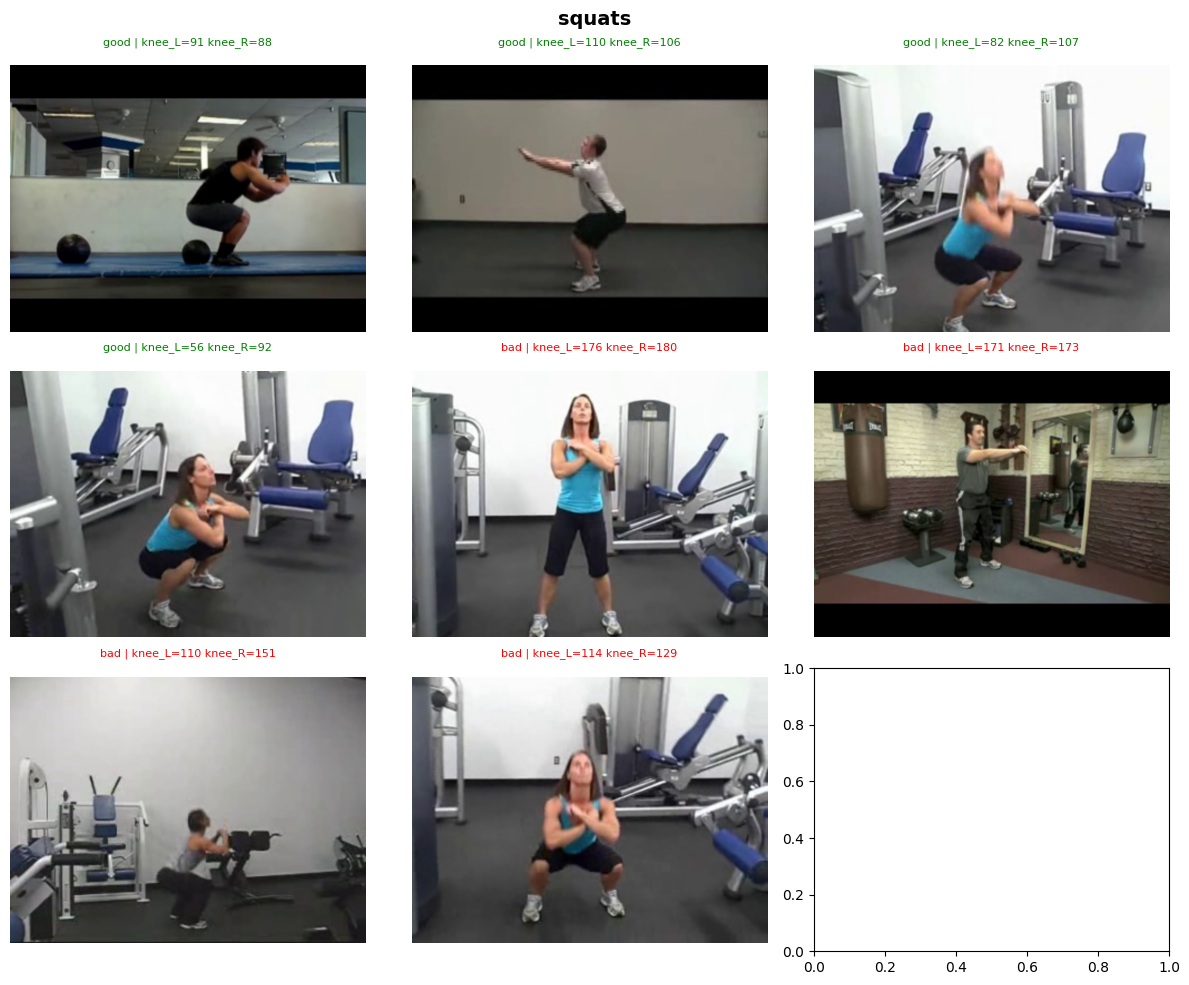

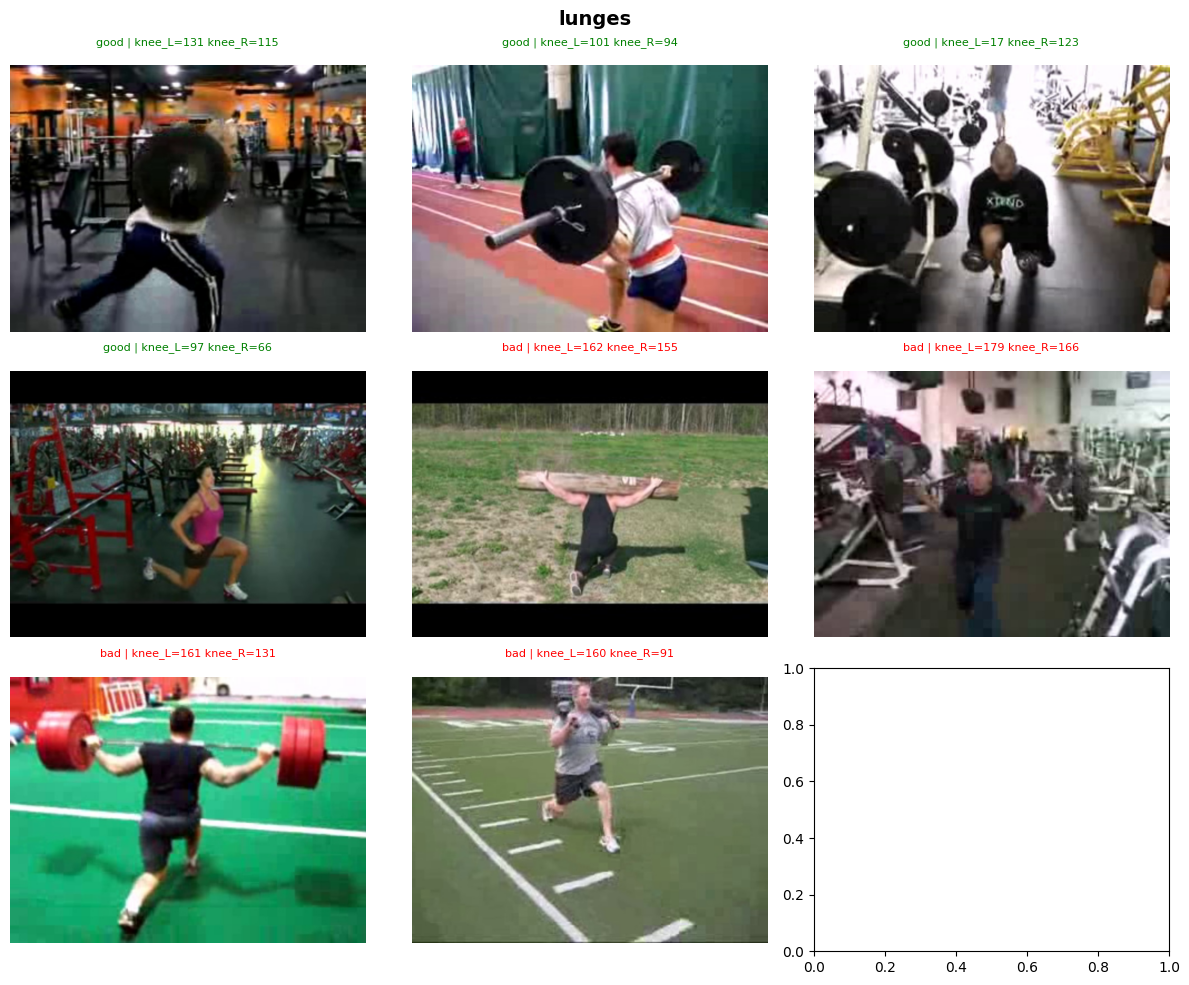

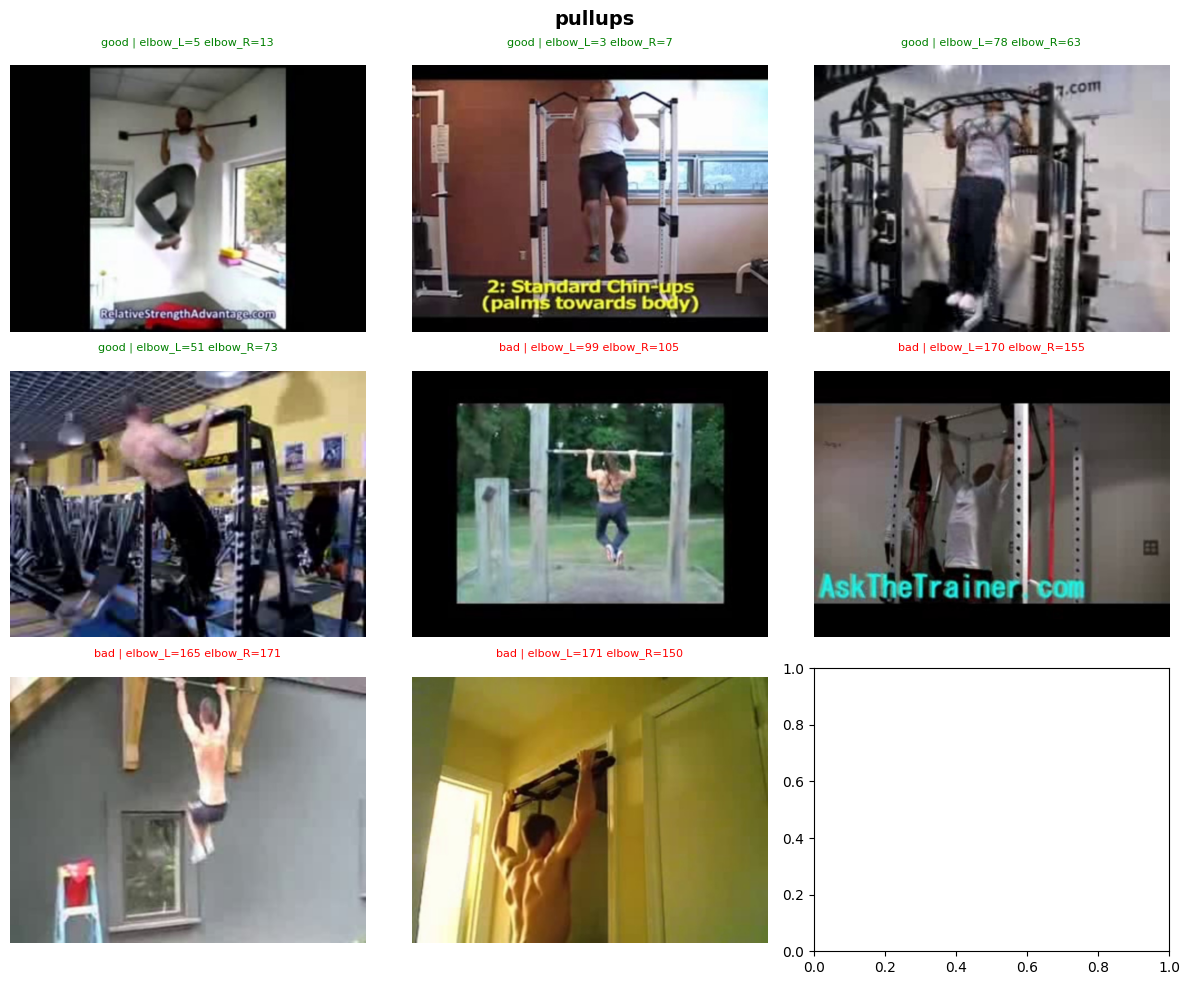

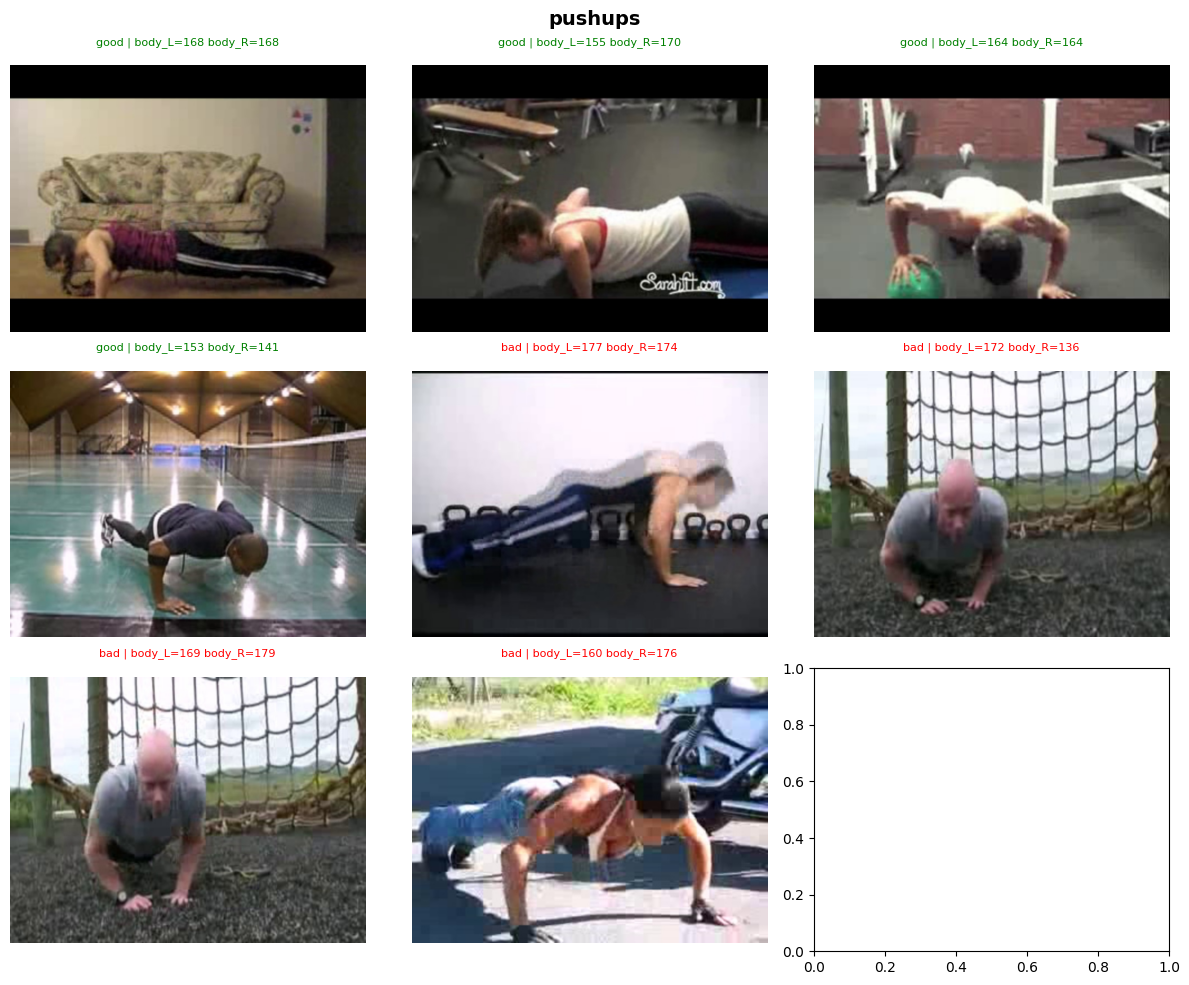

In [ ]:
def visualize_labels(df, class_label, n=9):
    """
    Show n random frames for a given class label
    with the label and key feature values overlaid
    """

    good = df[(df["label"] == class_label) & (df["form_label"] == "good")]
    bad  = df[(df["label"] == class_label) & (df["form_label"] == "bad")]

    n_each = n // 2
    subset = pd.concat([
        good.sample(min(n_each, len(good))),
        bad.sample(min(n_each, len(bad)))
    ])

    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    fig.suptitle(class_label, fontsize=14, fontweight="bold")
    axes = axes.flatten()

    for i, (_, row) in enumerate(subset.iterrows()):
        frame = cv2.imread(row["frame_path"])
        if frame is None:
            axes[i].set_visible(False)
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[i].imshow(frame)
        axes[i].axis("off")

        # Show relevant feature values per exercise
        label = row["label"]
        if label == "squats":
            info = f"knee_L={row['left_knee_angle']:.0f} knee_R={row['right_knee_angle']:.0f}\n"
        elif label == "pushups":
            info = f"body_L={row['left_body_line']:.0f} body_R={row['right_body_line']:.0f}\n"
        elif label == "lunges":
            info = f"knee_L={row['left_knee_angle']:.0f} knee_R={row['right_knee_angle']:.0f}\n"
        elif label == "pullups":
            info = f"elbow_L={row['left_elbow_angle']:.0f} elbow_R={row['right_elbow_angle']:.0f}\n"
        else:
            info = ""

        axes[i].set_title(
            f"{row['form_label']} | {info}",
            fontsize=8,
            color="green" if row["form_label"] == "good" else "red"
        )

    plt.tight_layout()
    plt.show()


# Check each class one by one
for label in train_df["label"].unique():
    visualize_labels(train_df, label, n=9)
    input(f"Press Enter to see next class...")  # pause between classes

## Training Phase
### We used MLP to train as our features are represented by vectors instead of images (pixels) ... better explanation coming

In [72]:
# Load necessary packages
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import random

In [80]:
MODEL_DIR    = "outputs/model"
MODEL_PATH   = "pose_landmarker.task"
os.makedirs(MODEL_DIR, exist_ok=True)

FEATURE_COLS = [
    "left_knee_angle", "right_knee_angle",
    "left_elbow_angle", "right_elbow_angle",
]

# Feedback messages per predicted class
FEEDBACK = {
    "squats_good":            "Good squat form!",
    "squats_bad":             "Fix squat: keep knees over toes, back straight",
    "pushups_good":           "Good pushup form!",
    "pushups_bad":            "Fix pushup: keep back flat, elbows at 45 degrees",
    "lunges_good":            "Good lunge form!",
    "lunges_bad":             "Fix lunge: front knee should not pass toes, torso should be facing forward",
    "pullups_good":           "Good pullup form!",
    "pullups_bad":            "Fix pullup: full range of motion, shoulders down"
}

def load_data(train_df, test_df):
    train_df = train_df.dropna(subset=["form_label"] + FEATURE_COLS)
    test_df  = test_df.dropna(subset=["form_label"] + FEATURE_COLS)

    X_train = train_df[FEATURE_COLS].values.astype(np.float32)
    X_test  = test_df[FEATURE_COLS].values.astype(np.float32)

    y_train_raw = (train_df["label"] + "_" + train_df["form_label"]).values
    y_test_raw  = (test_df["label"]  + "_" + test_df["form_label"]).values

    le = LabelEncoder()
    le.fit(np.concatenate([y_train_raw, y_test_raw]))
    y_train = le.transform(y_train_raw)
    y_test  = le.transform(y_test_raw)

    # Normalize features to same scale
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"Training samples : {len(X_train)}")
    print(f"Test samples     : {len(X_test)}")
    print(f"Classes          : {list(le.classes_)}")
    print(f"Feature count    : {X_train.shape[1]}\n")

    return X_train, X_test, y_train, y_test, le, scaler

In [81]:
X_train, X_test, y_train, y_test, le, scaler = load_data(train_df, test_df)

Training samples : 19006
Test samples     : 6681
Classes          : ['lunges_bad', 'lunges_good', 'pullups_bad', 'pullups_good', 'pushups_bad', 'pushups_good', 'squats_bad', 'squats_good']
Feature count    : 4

